In [5]:
import os, sys, warnings

if not sys.warnoptions:
    warnings.simplefilter("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import geoplot as gplt
import geoplot.crs as gcrs

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

color1 = "darkviolet"
color2 = "indigo"

![](https://i.imgur.com/rpOD15e.jpg)

<h1>
    <div style="padding: 30px; color: white; margin: 10; font-size: 60%; text-align: left; display: fill; border-radius: 10px; background-color: #FFFFFF; overflow: hidden; background-color: #FF5733"><b><span style="color: #FFFFFF">1 |</span></b> <b>INTRODUCTION</b>
    </div>
</h1>

<div style="color: white; display: fill; border-radius: 8px; font-size: 100%; letter-spacing: 1.0px;">
    <p style="padding: 5px; color: white; text-align: left;">
        <b><span style="color: #FF5733">PROBLEM STATEMENT</span></b>
    </p>
</div>

- There are a large number of factors that can affect the value of a house property (e.g. location, size, condition, time), these factors can change quite substantially from one property to another.
- The housing market itself is quite a volatile industry, and is quite dependent on demand and supply fluctuations, not to even mention economic factors such as interest rates & inflation, so it's quite a challenge to predict the price variation over time.
- It's also quite challenging to predict housing prices due to the limited data that is available, most datasets contain a limited number of features related to each property, that is why feature engineering is quite important.
- As a result, it is generally quite difficult to accurately predict property prices that take into account all the factors that influence it.
- The California housing dataset contains different house related attributes for properties located in California.

<div style="color: white; display: fill; border-radius: 8px; font-size: 100%; letter-spacing: 1.0px;">
    <p style="padding: 5px; color: white; text-align: left;">
        <b><span style="color: #FF5733">STUDY AIM</span></b>
    </p>
</div>

- The aim of the model is to predict the `median_house_value` which is our **target variable**.
- Overcome missing data with a basic **unsupervised learning** data imputation.
- Identification of **outliers** in a dataset.
- Understand how to turn a simple model into your own **sklearn** comparable class; our aim won't be to create the most perfect model.

<div style="color: white; display: fill; border-radius: 8px; font-size: 100%; letter-spacing: 1.0px;">
    <p style="padding: 5px; color: white; text-align: left;">
        <b><span style="color: #FF5733">NOTEBOOK COVERS</span></b>
    </p>
</div>

- Introduction to basic ML principles such as `missing data`, `scaling`, `feature engineering` and `outliers`.
- A basic introduction to `sklearn` compatible classes, `model exploration` & `model modification` in an attempt to improve our model.

<div style="color: white; display: fill; border-radius: 8px; font-size: 100%; letter-spacing: 1.0px;">
    <p style="padding: 5px; color: white; text-align: left;">
        <b><span style="color: #FF5733">MODEL SELECTION</span></b>
    </p>
</div>

We'll use an existing model: `Bayesian Linear Regression` in class structure that can be used with sklearn's `Pipeline` and `cross validation` options, so we can use it here.<br/>



<h1>
    <div style="padding: 30px; color: white; margin: 10; font-size: 60%; text-align: left; display: fill; border-radius: 10px; background-color: #FFFFFF; overflow: hidden; background-color: #FF5733"><b><span style="color: #FFFFFF">2 |</span></b> <b>DATA PREPARATION</b>
    </div>
</h1>

<h3>
    <b><span style="color: #FF5733"> 2.1 |</span> Loading the dataset</b>
</h3>

- `df.info()`, `describe()`, `head()` are probably one of the first things we might want to inspect having a pandas dataframe. Showing feature names, limits/stats and a few first columns respectively, to get a first impression of the data.
- I have made some minor adjustments to the [original dataset](https://www.kaggle.com/camnugent/california-housing-prices) and pulled out some random data from all but two coordinate features, so we can do some data imputation.

In [6]:
# load the dataset
df = pd.read_csv("housing.csv")

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [8]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


- `.info()` is perhaps a good starting point, having read and loaded data into a pandas dataframe.
- `RangeIndex` tells us the maximum loaded data instance, so we can quickly identify columns with missing data.
- `pandas` can read a wide range of data types; so `Dtype` information is very handy to know.
- `.head()` is a nice way to peak into our dataset. `.tail()` is also a quick way to scroll to the bottom of the dataset.

In [9]:
# Let's return all columns with missing data as well:
df[df.isnull().any(axis=1)]  # any missing data in columns

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN
20372,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,258100.0,<1H OCEAN


<h3 style="font-weight:bold;">
    <span style="color:#FF5733;"> 2.2 |</span> Data imputation
</h3>

- Note that we have a number of features with some missing data, but not too many instances overall (207/20640) or just 1%.
- Let's try an `Unsupervised Learning (UL)` approach based on the `kNN` model. We can use the function below and pass a dataframe to generate an imputed dataframe.

<h4 style="font-weight:bold;">
    <span style="color:#FF5733">kNN Unsupervised Learning Imputation</span>
</h4>

- Function to impute missing data using an unsupervised model.

In [10]:
def impute_knn(df: pd.DataFrame):
    """Take as input a pandas DataFrame, and output a DataFrame with NaN imputed"""
    # Select only numerical columns in df
    ldf = df.select_dtypes(include=[np.number])
    # Select categorical columns in df
    ldf_putaside = df.select_dtypes(exclude=[np.number])
    # Return a list with the columns having missing data...
    # ["total_bedrooms"]
    cols_nan = ldf.columns[ldf.isna().any()].tolist()
    # and without missing data.
    # ["longitude", "latitude",...] i.e. all but "total_bedrooms"
    cols_no_nan = ldf.columns.difference(cols_nan).values

    for col in cols_nan:
        # Rows with missing data will become our test set.
        imp_test = ldf[ldf[col].isna()]
        # All rows with no missing data.
        imp_train = ldf.dropna()
        # KNR Unsupervised Approach
        model = KNeighborsRegressor(n_neighbors=5)
        knr = model.fit(imp_train[cols_no_nan], imp_train[col])
        ldf.loc[df[col].isna(), col] = knr.predict(imp_test[cols_no_nan])

    return pd.concat([ldf, ldf_putaside], axis=1)

In [11]:
# Call the function that imputes missing data.
df2 = impute_knn(df)
# Print a summary of the df2. Now we have a full feature matrix
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


<h3 style="font-weight:bold;">
    <span style="color:#FF5733";> 2.3 |</span> Creating a hold-out set
</h3>

- We want to reserve some data and use it to see how good the model is at prediction on unseen data. So let's create it using `train_test_split`.

`trdata` : Training Data Subset (Let's inspect the data as if we only had this data)<br/>
`tedata` : Test Data Subset (Use this subset for model evaluation)

In [12]:
# A 70/30 split should do
trdata, tedata = train_test_split(df2, test_size=0.3, random_state=43)

<h1>
    <div style="padding: 30px; color: white; margin: 10; font-size: 60%; text-align: left; display: fill; border-radius: 10px; background-color: #FFFFFF; overflow: hidden; background-color: #FF5733"><b><span style="color: #FFFFFF">3 |</span></b> <b>EXPLORATORY DATA ANALYSIS</b>
    </div>
</h1>

We want to know a little more about our data, so a simple data exploration approach is conducted here.

<h3 style="font-weight:bold;">
    <span style="color:#FF5733"> 3.1 |</span> Univariate histograms
</h3>

Let's look at our data distribution, using `univariate analysis` (analysis of 1 variable).<br/>
What we might look for in histograms:
- Data distribution (certain models prefer less skewed distributions)
- Outliers (Low Noise Assumption can be detrimental to model performance)
- Odd patterns in data (Data abnormalities also affect model performance)
- Axis Scale (Feature scale values can affect a model's performance)

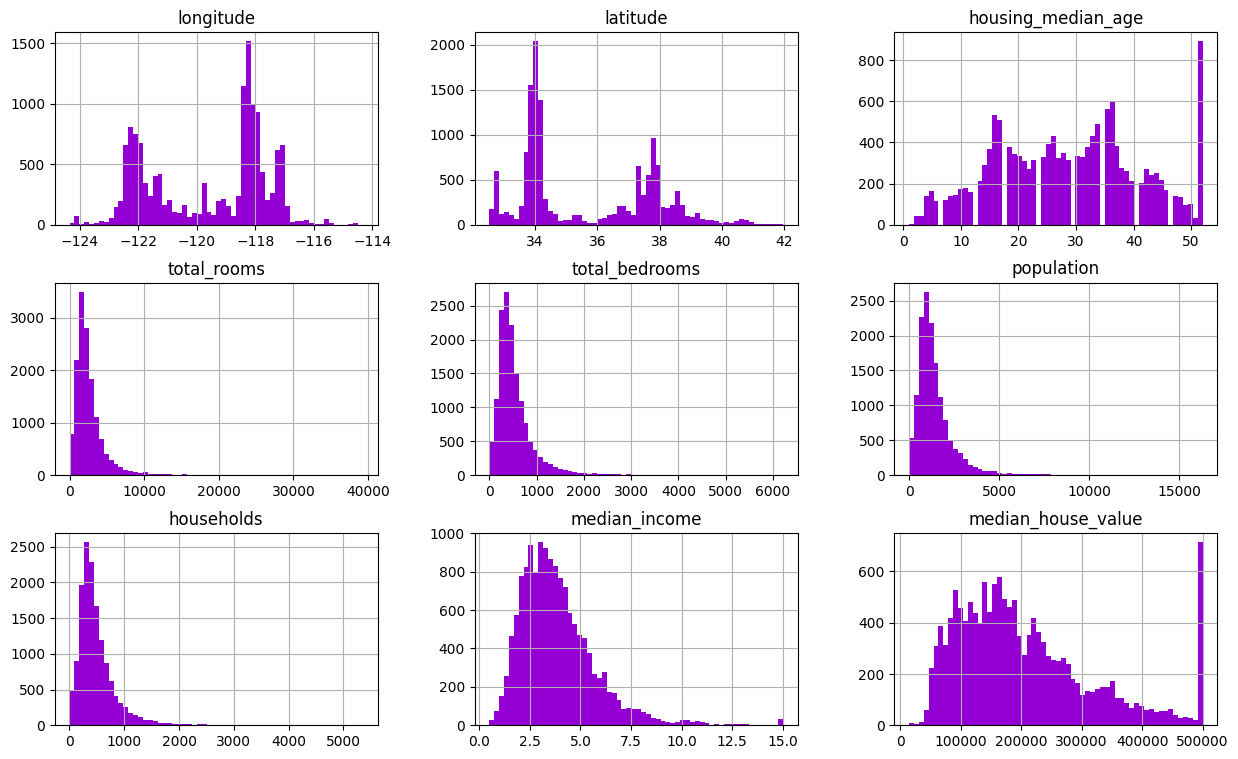

In [13]:
trdata.hist(bins=60, figsize=(15, 9), color=color1)
plt.show()

<h4 style="font-weight:bold; color:#FF5733">
    Odd Patterns & Outliers
</h4>

Data distributions that slightly stick out:
- On first impression, a few outlier (inconsistent with entire set) groups are present in our data; possibly due to the way in which the data was sampled ("housing_median_age" and "median_house_value")
- `House_median_age` is one possible feature with such outliers. Also, having a lot of local peaks (all are quite gradual) but one really odd peak at the maximum value stands out. It has some slight discontinuity in data (which becomes visible with the adjustment of bins)
- Feature `Median_house_value` has an odd peak at its maximum value (around 500k), which could be an outlier.

<h4 style="font-weight:bold; color:#FF5733">
    Less Noticeable Outliers
</h4>

- We have quite a few skewed (less centralized) data distributions, 6 features have such distributions, which is quite a lot and slightly concerning since we are going to use a relatively simple model.
- The range of the x-axis for some of these features is quite broad (e.g. `population`), indicating we have quite a few outliers, but unlike the first two we can apply `transformation` to features and attempt to correct it.
- Population, total_bedrooms and total_rooms represent somewhat connected things, also have similar distribution which is skewed towards smaller values.

<h3 style="font-weight:bold;">
     <span style="color:#FF5733"> 3.2 |</span> Bivariate Correlation Matrix
</h3>

- Bivariate (two features) Two-Feature relation; `correlation matrix`
- Very fast way to understand something about the dataset.
- Correlation matrix contains only information about the linear similarity of two feature relations

What we might look for:

- Often emphasized that `too highly` or `too lowly correlated` features should be dropped
- Any signs of nonlinearity in the dataset, such as a fair few low linear correlation values
- High correlation values between multiple features could indicate that these features might indicate similar things

In [14]:
def corrMat(df: pd.DataFrame, id=False):
    """Function to plot correlation of features"""
    ldf = df.select_dtypes(include=[np.number])
    corr_mat = ldf.corr().round(2)
    fig, ax = plt.subplots(figsize=(6, 6))
    mask = np.zeros_like(corr_mat, dtype=np.bool)
    mask[np.triu_indices_from(mask)] = True

    sns.heatmap(
        corr_mat,
        mask=mask,
        vmin=-1,
        vmax=1,
        center=0,
        cmap="plasma",
        square=False,
        lw=2,
        annot=True,
        cbar=False,
    )
    plt.show()

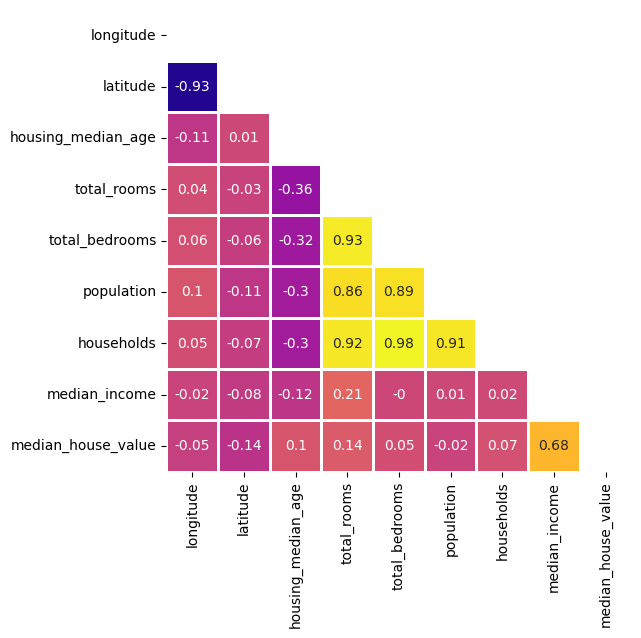

In [15]:
# Plot masked numpy correlation matrix
corrMat(trdata)

- Target variable `median_house_value` is very mildly correlated to all but one feature here: `median_income`, so one might outline this as an important feature.
- A correlation of -0.02 or -0.05 (`population`/`longitude`) to the target variable `median_house-value` might be worth dropping, but they might not be. In fact, a low value isn't exatly a reason to drop a feature. It could simply imply that the data is spread quite a lot, which is a strong indicator of nonlinearity.
- It is often advised to drop such features, especially for less complex models, as the model probably won't be able to pick up on one feature with such nonlinearity, let alone multiple.
- It is possible to plot a shifted matrix, which looks a little nicer.

<h3 style="font-weight:bold;">
    <span style="color:#FF5733;"> 3.3 |</span> Bivariate Scattered Data
</h3>

- Pairplots/Scatter Matrices are very insightful and can be used to find interesting scatter patterns in `bivariate` (two feature data plots) relations
- Scatter plots allow the addition of `color` labelling, however it's often quite difficult to distinguish between `color` labels in a scattered matrix

What we might look for:
- Irregular two feature patterns or outliers (multiple features give a clearer picture of outlier)
- Two dimensional data clusters (using KDE approximation)
- Two feature linear correlation value visualization in two dimensional space (is the data sorted linearly or completely random?)

In [16]:
def snsPairGrid(df: pd.DataFrame):
    """Draw a Bivariate Seaborn Pairgrid with KDE density\n
    and scatter plot of df features."""
    g = sns.PairGrid(df, diag_sharey=False, corner=True)
    g.figure.set_size_inches(14, 13)
    # draw KDE approximation on the diagonal
    g.map_diag(sns.kdeplot, lw=2)
    # scattered plot on lower half
    g.map_lower(sns.scatterplot, s=15, edgecolor="k", linewidth=1, alpha=0.4)
    # KDE approximation on lower half
    g.map_lower(sns.kdeplot, cmap="plasma", n_levels=10)
    plt.tight_layout()

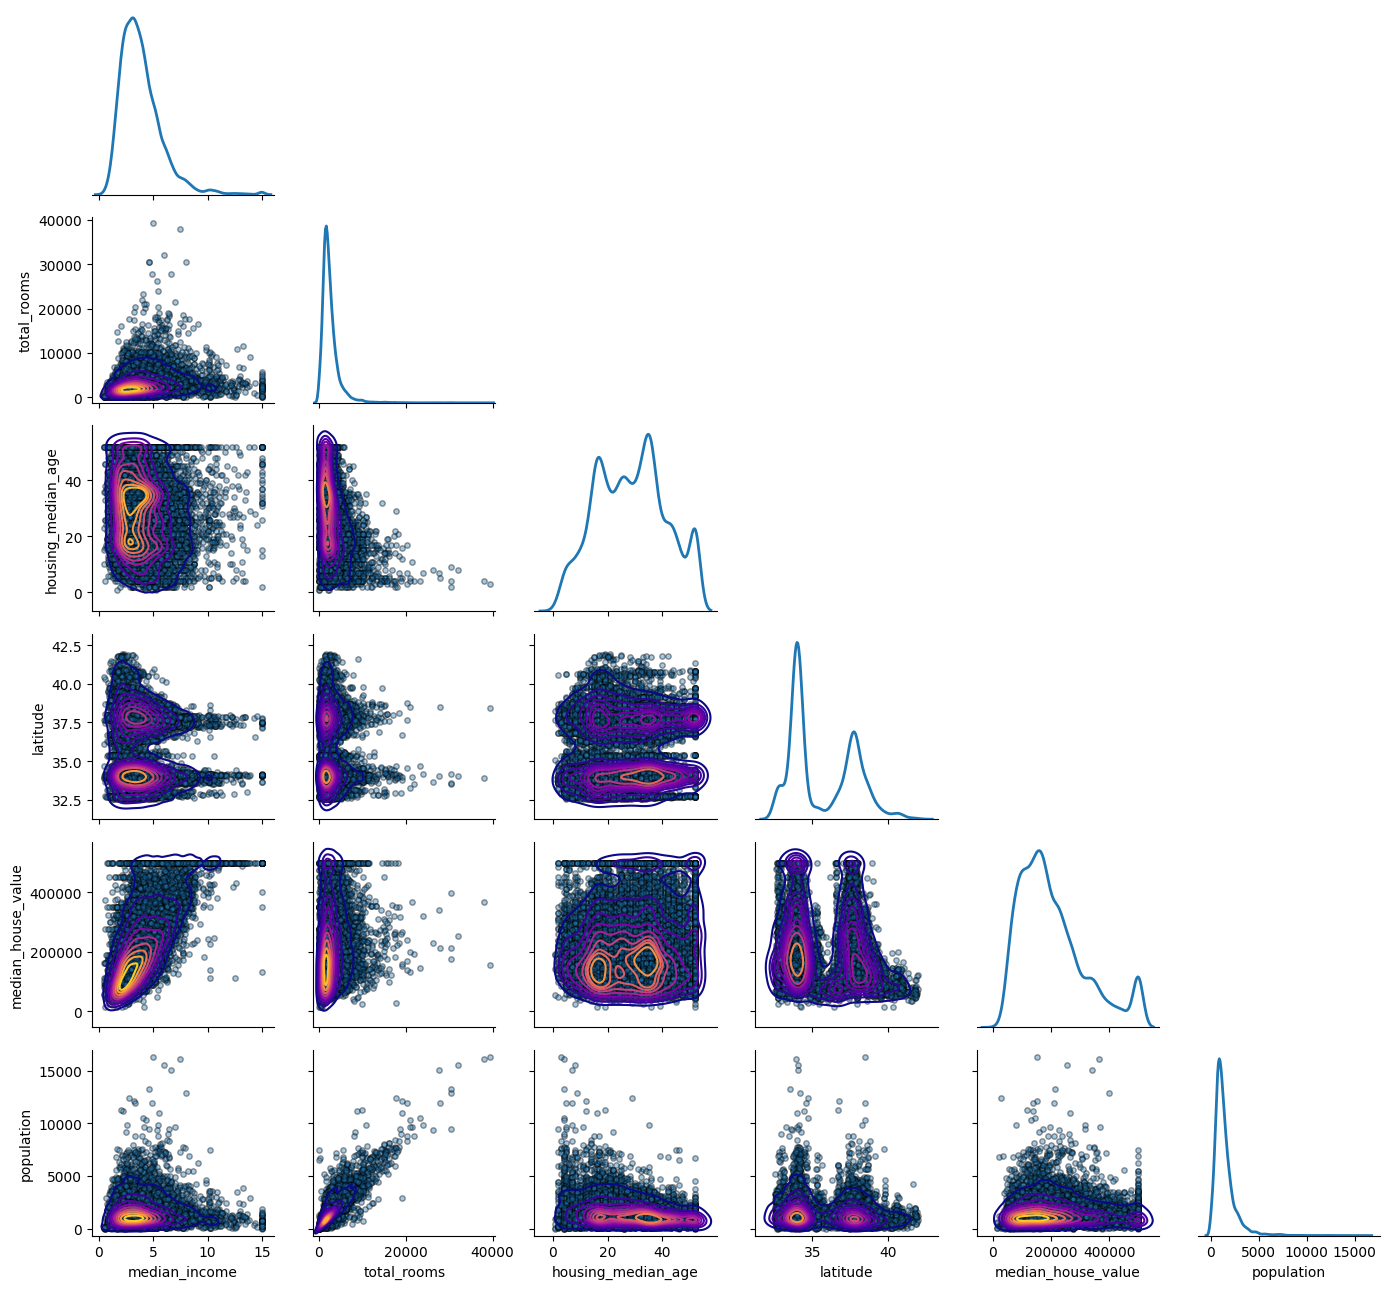

In [17]:
# Seaborn gets a little slow, let's plot some interesting features
tlist = ["median_income", "total_rooms", "housing_median_age", "latitude", "median_house_value", "population"]
snsPairGrid(trdata[tlist])

<h4 style="font-weight:bold;color:#FF5733;">
    Relating to "Median_House_Value"
</h4>

- `median_house_value` and `median_income` relation looks quite linear, with a fair bit of deviation normal to the linear line, we can also note a visible upper limit for all values of `median_income`, which in two dimensions, definitely looks out of place.
- In `median_house_age` vs `median_house_value` relation, it looks like the data is completely spread out all over the place; KDE helping the identification of two peaks roughly 20 yrs apart, perhaps these peaks are associated with increasing affordability (given they are concentrated in the lower half)
- We can note an additional peak near the peak values of both features as well. The relation is very nonlinear, being scattered everywhere, having data in almost all parts of the graph.
- `median_house_value` and `total_rooms` , `population` seem like quite complex features to model, KDE suggests it's heavily concentrated at lower values for the two, with a fair bit at larger values and a lot of data outside the main clusters, classifiable as `outliers`.
- Many of our features have quite different axis scales, higher values might be interpreted as more important, so scaling should definitely be considered.

<h3 style="font-weight:bold;">
    <span style="color:#FF5733"> 3.4 |</span> Geospatial Multivariate Data
</h3>

- `Multivariate` visualization can be even more insightful than `bivariate`. Adding "hue"/color to scattered data gives the data an extra dimension we can interpret, provided there's minimal overlap
- Geographing plotting is one form of such visualization. It would be interesting to understand how geography influences various features.
- We're dealing with geographical data, so [geopandas](https://geopandas.org/) is quite useful, so is `folium` and plotly
- Other modules you might like to add (mainly for 3D) [k3d](https://github.com/K3D-tools/K3D-jupyter/) and [pyvista](https://github.com/pyvista/pyvista) are awesome for multivariate visualization too.

In [18]:
def plotTwo(df: pd.DataFrame, lst: list):
    """
    Plot two geopandas plots side by side.\n
    The input list contains features of names found in dataframe.
    """
    # load california from module, common for all plots
    cali = gpd.read_file(gplt.datasets.get_path("california_congressional_districts"))
    cali = cali.assign(area=cali.geometry.area)

    # create a geopandas geometry feature; input dataframe should
    # contain .longitude, .latitude
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude))
    proj = gcrs.AlbersEqualArea(central_latitude=37.16611, central_longitude=-119.44944)  # related to view

    ii = -1
    fig, ax = plt.subplots(1, 2, figsize=(21, 6), subplot_kw={"projection": proj})

    for i in lst:
        ii += 1
        tgdf = gdf.sort_values(by=i, ascending=True)
        gplt.polyplot(cali, projection=proj, ax=ax[ii])  # the module already has california
        gplt.pointplot(tgdf, ax=ax[ii], hue=i, cmap="plasma", legend=True, alpha=1.0, s=3)
        ax[ii].set_title(i)

    plt.tight_layout()
    plt.subplots_adjust(wspace=-0.5)

In [19]:
trdata.info()

<class 'pandas.DataFrame'>
Index: 14448 entries, 11440 to 14148
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           14448 non-null  float64
 1   latitude            14448 non-null  float64
 2   housing_median_age  14448 non-null  float64
 3   total_rooms         14448 non-null  float64
 4   total_bedrooms      14448 non-null  float64
 5   population          14448 non-null  float64
 6   households          14448 non-null  float64
 7   median_income       14448 non-null  float64
 8   median_house_value  14448 non-null  float64
 9   ocean_proximity     14448 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.2 MB


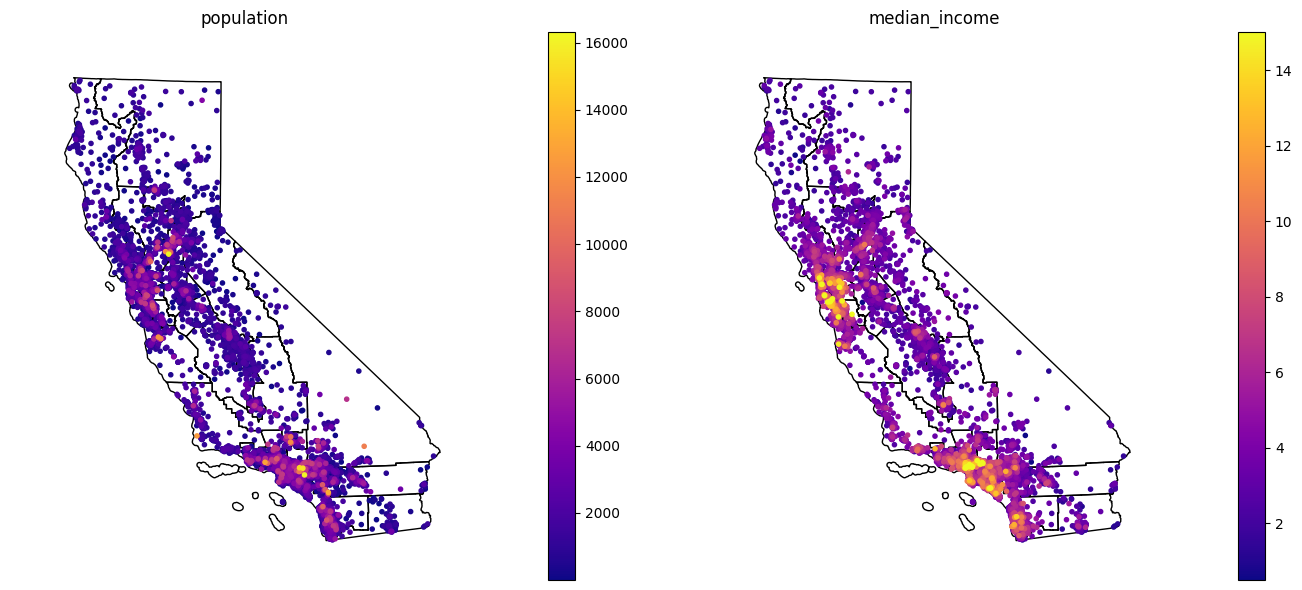

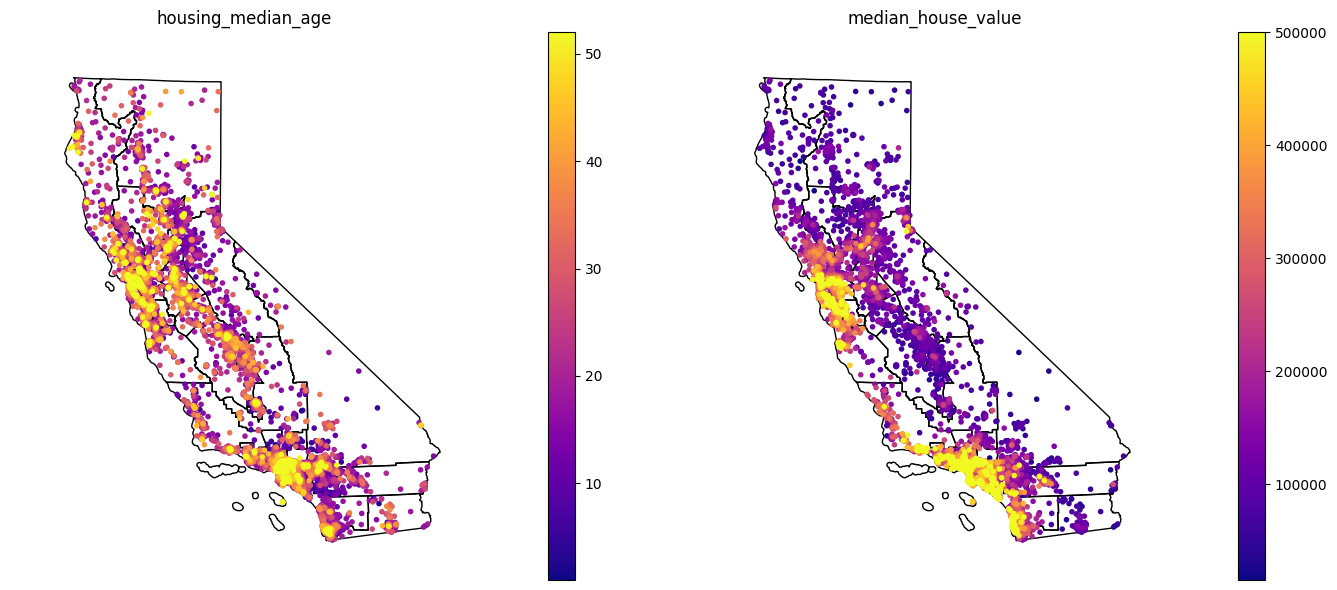

In [20]:
# Call function that plots two geopandas plots
plotTwo(trdata, ["population", "median_income"])
plotTwo(trdata, ["housing_median_age", "median_house_value"])

- For our target variable, `median_house_value`, just by looking at these graphs, one could immediately note some patterns; `geography(location)` and `median_house_income` show clear relation; generally increasing the close you get to the two main clusters, so these two features would probably be important.

- `Housing_median_age` for a lot of regions is also strongly correlated to the target variable, but in many regions it isn't (slightly more inland), so it's not so clear cut. The relation is probably just nonlinear. Recalling the pair plot, we saw quite a lot of spread in the data, however one could notice two main clusters from that graph, which showed some linearity aspect.

- `Population` is a little more tricky. It's somewhat correlated, although we have a few outliers (not even visible on the univariate histogram) which make it harder to see a relation as the values are more bunched up in the < 10k group, but there does tend to be a relation though, as indicated by the `correlation` value.

<h1>
    <div style="padding: 30px; color: white; margin: 10; font-size: 60%; text-align: left; display: fill; border-radius: 10px; background-color: #FFFFFF; overflow: hidden; background-color: #FF5733"><b><span style="color: #FFFFFF">4 |</span></b> <b>REVIEWING OUTLIERS</b>
    </div>
</h1>

From pairplot data we noted the existence of outliers, this is more of a manual process of identification, you might be interested in an automated approach using EllipticEnvelope, an example found in [Chris Albon's Cookbook](https://chrisalbon.com/machine_learning/preprocessing_structured_data/detecting_outliers/)

<h4 style="font-weight:bold;color:#FF5733">
    Outlier @ housing_median_age == 52
</h4>

We inspected the dataset histogram, and noted a rather odd cluster at a value of 52, 1D data doesn't quite tell the entire story, certainly our histogram data transitions quite steadily, but perhaps during this year it was very affordable. 2D pairplots tend to show this data as being somewhat more like a constraint more than anything, looking very odd compared to the rest of the data (lines in data). Overall, it's not entirely conclusive.

<h4 style="font-weight:bold;color:#FF5733">
    Outlier @ median_house_value == 500,001
</h4>

Unlike housing_median_age, it is very doubtful that the outlier spike is not a categorically defined summation of all cases above the maximum median_house_value, let's remove this subset, and keep the other.


<h4 style="font-weight:bold;color:#FF5733">
    Less noticable outliers
</h4>

Having just plotted `population` in a `multivariate` plot, we would have noted how the scale created values that are barely visible to the eye, in fact, a model with poorly allocated weights to these outliers, can severely degrade in accuracy, one counter to these outliers is a weight function approach, such as `Inverse Distance Weighting (IDW)` in models such as `Weighted Least Squares (WLS)` or `Covariance Functions` in [`Gaussian Process Models`](https://www.kaggle.com/andreikozlov/uci-airfoil-noise-prediction), `BR()` unfortunately doesn't have this functionality, so we'll have to attempt a common approach known as `skewness correction` via feature transformation. I thought we'd give it a go and attempt to implement these functions into the `BR()` model as well, why not.

- Let's remove the outlier for `median_house_value` by simply selecting the maximum (which works here).


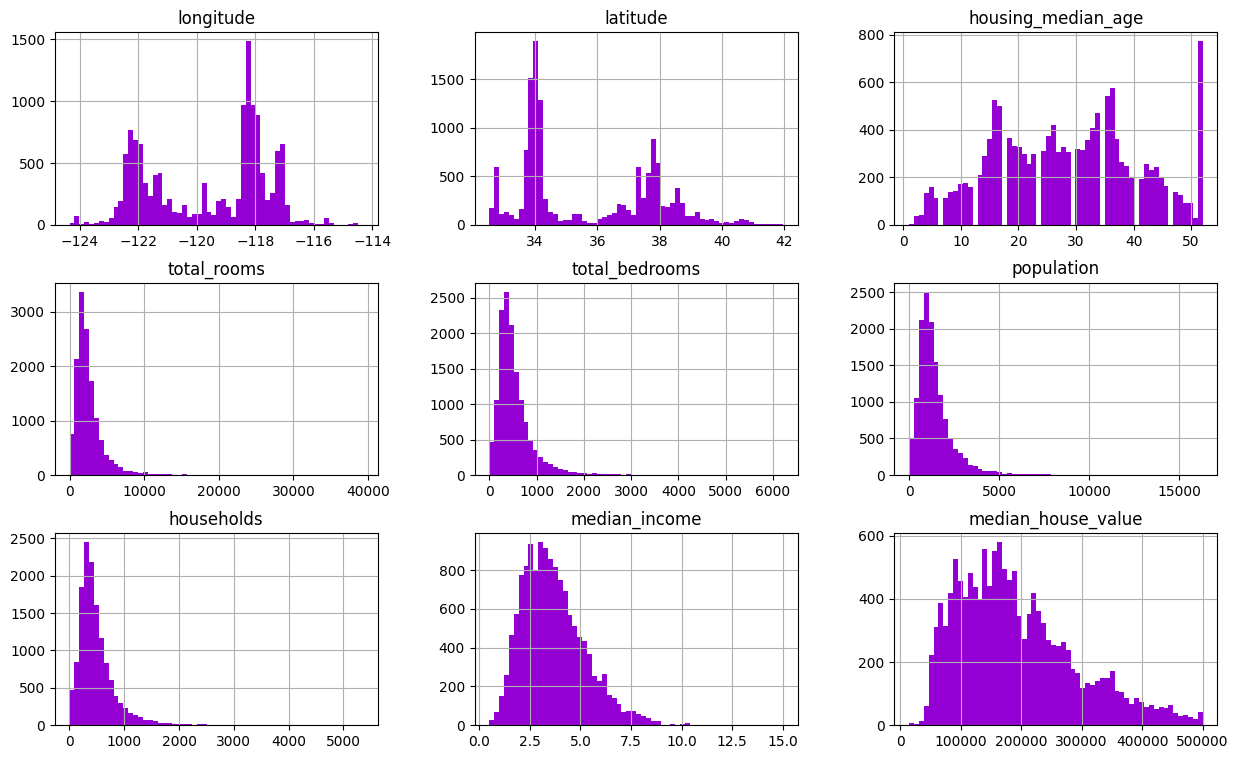

In [21]:
# trdata_upd : training data with outliers removed
# get the maximum value
maxval2 = trdata["median_house_value"].max()
trdata_upd = trdata[trdata["median_house_value"] != maxval2]
tedata_upd = tedata[tedata["median_house_value"] != maxval2]
# looks like it's completely removed.
trdata_upd.hist(bins=60, figsize=(15, 9), color=color1)
plt.show()

<h1>
    <div style="padding: 30px; color: white; margin: 10; font-size: 60%; text-align: left; display: fill; border-radius: 10px; background-color: #FFFFFF; overflow: hidden; background-color: #FF5733"><b><span style="color: #FFFFFF">5 |</span></b> <b>FEATURE ENGINEERING</b>
    </div>
</h1>

- Creation and modification of the feature matrix data, `Feature Engineering` is quite important and quite a cyclical process; we want to input a feature matrix that will help teach a model something useful.
- We want to make sure we feed the model data that is most relevant to the prediction of a target variable, perhaps as less overlapping as possible as well.
- Features with very high correlation teach a model similar things, multiple times, maybe consider combing them and dropping the others.

<h4 style="font-weight:bold;color:#FF5733">
    Some things we could try:
</h4>

- In this problem, we don't have a lot of features to play around with, but we noted that we have a few which are quite similar. Let's create a relatively simple combination from them, and drop the rest.
- We'll also create a feature which combines both coordinates as we saw in the multivariate data, there is a relation that changes quite steadily on the diagonal (moving closer to the ocean and inland).

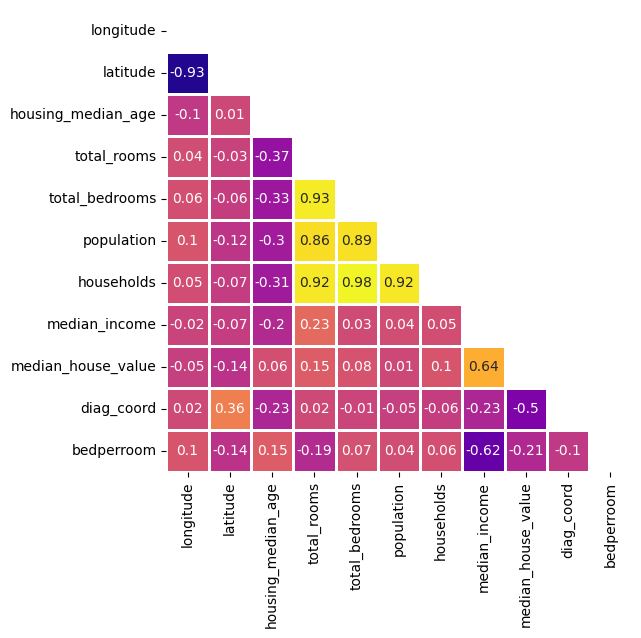

In [22]:
# Make a feature that contains both longitude & latitude
# 'diagonal coordinate works for this coord
trdata_upd["diag_coord"] = trdata_upd["longitude"] + trdata_upd["latitude"]
# feature with bedrooms/room ratio
trdata_upd["bedperroom"] = trdata_upd["total_bedrooms"] / trdata_upd["total_rooms"]
corrMat(trdata_upd)

# Update test data as well
tedata_upd["diag_coord"] = tedata_upd["longitude"] + tedata_upd["latitude"]
tedata_upd["bedperroom"] = tedata_upd["total_bedrooms"] / tedata_upd["total_rooms"]

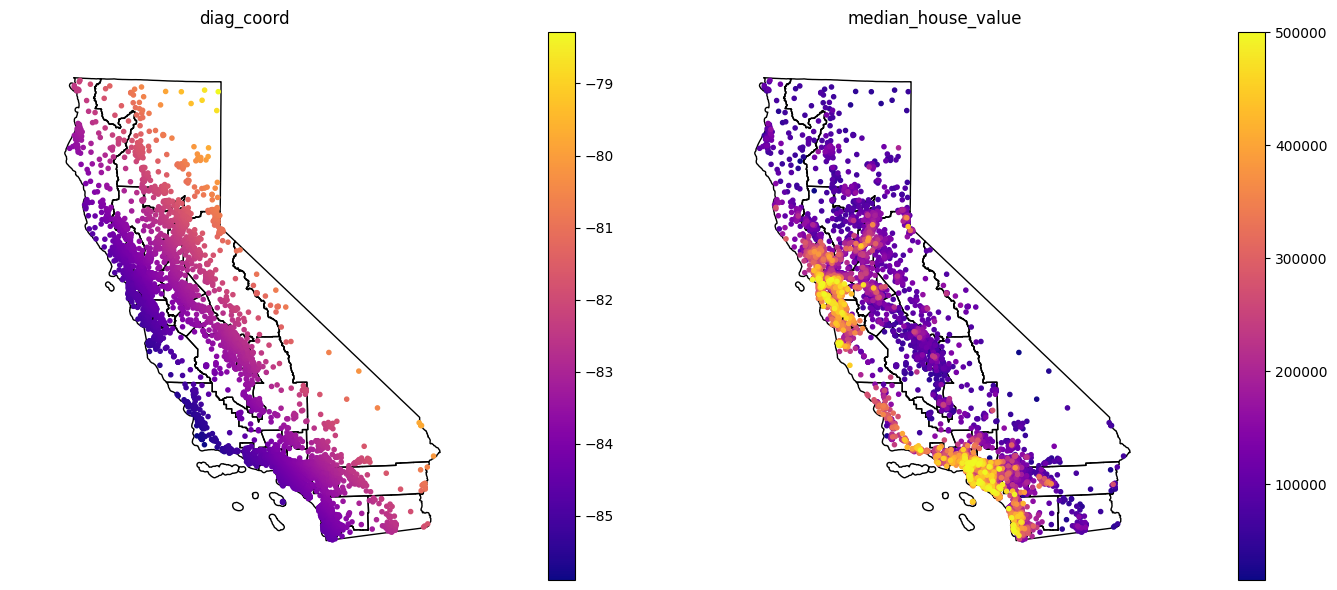

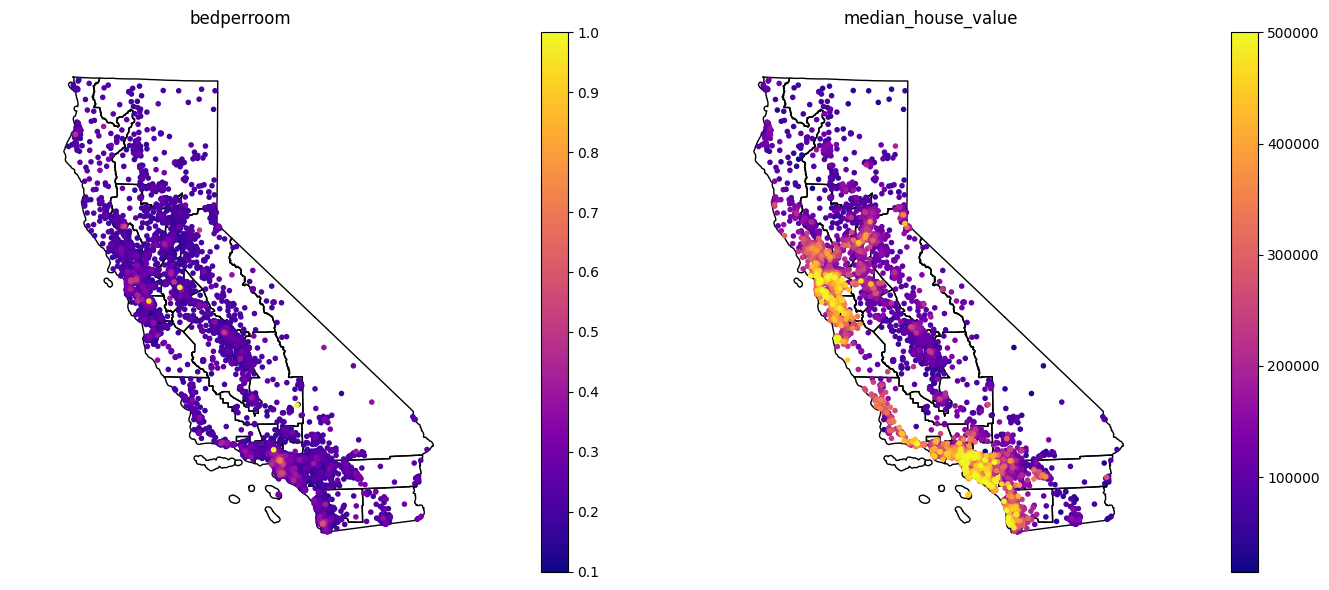

In [23]:
# Let's plot them as well
plotTwo(trdata_upd, ["diag_coord", "median_house_value"])
plotTwo(trdata_upd, ["bedperroom", "median_house_value"])

- We can note a clear correlation for `diag_coord` & our target variable from the map plot (inverse correlation).
- On the other hand, `bedperroom` was not as illuminating as hoped, it's still one of the more highly correlated features though, as indicated in the correlation matrix.

<h1>
    <div style="padding: 30px; color: white; margin: 10; font-size: 60%; text-align: left; display: fill; border-radius: 10px; background-color: #FFFFFF; overflow: hidden; background-color: #FF5733"><b><span style="color: #FFFFFF">7 |</span></b> <b>ML MODELS TO PREDICT MEDIAN HOUSE VALUE</b>
    </div>
</h1>

<h3 style="font-weight:bold;">
    <span style="color:#FF5733;"> 7.1 | </span>
    <span>Baseline Bayesian Regression Models</span>
</h3>

For the base models, let's investigate three things using a **5-fold Cross Validation** Approach:
- Foremost, let's create a simple baseline model, `DummyRegressor()`.
- We have two ready dataframes, the original feature dataframe `trdata` & `trdata_upd`, with the additional two features. We'll use the automatically tuned hyperparameter (`lamda` & `alpha`) for all BR() generated models in the crosss validation.
- Additionaly we noted that several features (`total_rooms`, `total_bedrooms`, `population`) have very high correlation to one another, so it's interesting to find out if a removal of a few of them would have any effect on the model performance.